In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from physics import compute_flux_normalized, compute_flux, GasState
from train import UniformRandomSampler, GAS_STATE_DIM, TRAIN_BOUNDS

import jax
import jax.random as jr
import jax.numpy as jnp


FLUX_SCALE: [ 10.2027481   25.93884772 336.96303935]


In [2]:
batch_size = 2**16
sampler = UniformRandomSampler()
bounds = TRAIN_BOUNDS

x_batch = sampler.draw_batch(jr.PRNGKey(0), batch_size, GAS_STATE_DIM+1, bounds)
compute_flux_normalized_of_x = lambda x: compute_flux_normalized(x[0], GasState.from_array(x[1:]))
flux_normalized_eval = jax.vmap(compute_flux_normalized_of_x)(x_batch)

compute_flux_of_x = lambda x: compute_flux(x[0], GasState.from_array(x[1:]))
flux_eval = jax.vmap(compute_flux_of_x)(x_batch)

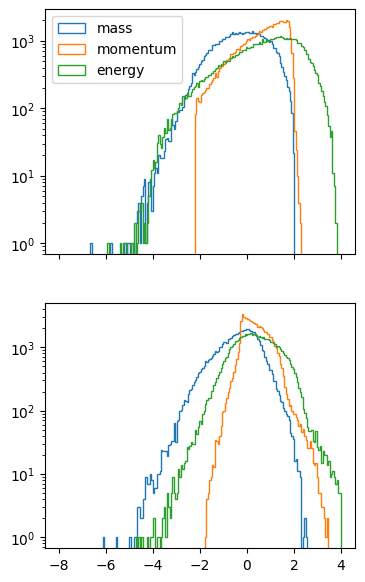

In [3]:
bins = np.linspace(-8, 4, 200)

fig, axs = plt.subplots(2, 1, figsize=(4, 7), sharex=True)

ax = axs[0]
if True:
    ax.hist(jnp.log10(jnp.abs(flux_eval[..., 0])), bins=bins, histtype='step', label='mass')
    ax.hist(jnp.log10(jnp.abs(flux_eval[..., 1])), bins=bins, histtype='step', label='momentum')
    ax.hist(jnp.log10(jnp.abs(flux_eval[..., 2])), bins=bins, histtype='step', label='energy')
    ax.set_yscale('log')
    ax.legend()

ax = axs[1]
if True:
    ax.hist(jnp.log10(jnp.abs(flux_normalized_eval[..., 0])), bins=bins, histtype='step', label='mass')
    ax.hist(jnp.log10(jnp.abs(flux_normalized_eval[..., 1])), bins=bins, histtype='step', label='momentum')
    ax.hist(jnp.log10(jnp.abs(flux_normalized_eval[..., 2])), bins=bins, histtype='step', label='energy')
    ax.set_yscale('log')

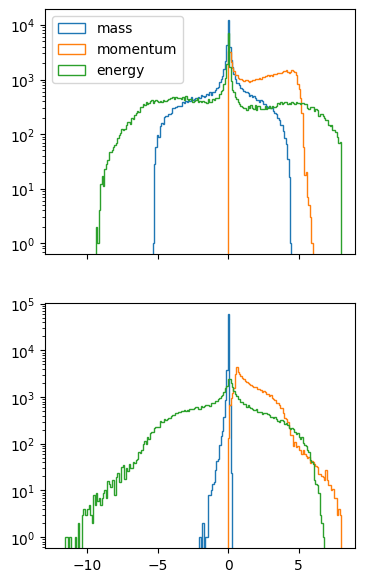

In [4]:
bins = np.linspace(-12, 8, 200)

fig, axs = plt.subplots(2, 1, figsize=(4, 7), sharex=True)

ax = axs[0]
if True:
    ax.hist(jnp.arcsinh(flux_eval[..., 0]), bins=bins, histtype='step', label='mass')
    ax.hist(jnp.arcsinh(flux_eval[..., 1]), bins=bins, histtype='step', label='momentum')
    ax.hist(jnp.arcsinh(flux_eval[..., 2]), bins=bins, histtype='step', label='energy')
    ax.set_yscale('log')
    ax.legend()

ax = axs[1]
if True:
    ax.hist(jnp.arcsinh(flux_normalized_eval[..., 0]/100), bins=bins, histtype='step', label='mass')
    ax.hist(jnp.arcsinh(flux_normalized_eval[..., 1]), bins=bins, histtype='step', label='momentum')
    ax.hist(jnp.arcsinh(flux_normalized_eval[..., 2]), bins=bins, histtype='step', label='energy')
    ax.set_yscale('log')

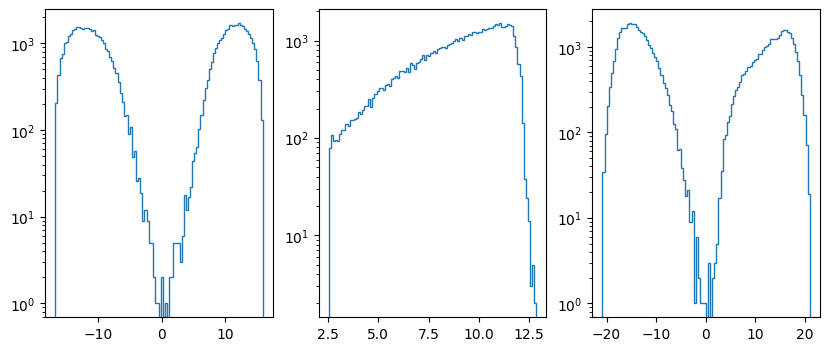

In [7]:
# for f in [0.01, 1, 10, 100, 1000]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))

for i,f in enumerate([1e-5, 1e-3, 1e-5]):
    ax = axs[i]
    # ax.hist(jnp.arcsinh(flux_normalized_eval[..., i]/f), bins=200, histtype='step')
    ax.hist(jnp.arcsinh(flux_eval[..., i]/f), bins=100, histtype='step')
    ax.set_yscale('log')

In [ ]:
f * jnp.sinh()

In [8]:
print(jnp.min(jnp.abs(flux_eval), axis=0))
# jnp.arcsinh(f / 1e-6)

[4.07526395e-06 6.33623158e-03 3.23839740e-08]
